# Análisis de perfiles clínicos asociados al estado de la microbiota intestinal mediante aprendizaje no supervisado

# Autores:
Ana Paulina Delgadillo Bustos, Evelin Sarahi Corona Corona, Ana Julia Ceja Rodriguez, German Preciat

# Descripción del proyecto

Este proyecto tiene como objetivo explorar el estado de la microbiota intestinal sin recurrir a técnicas de secuenciación, utilizando únicamente variables clínicas, fisiológicas y de estilo de vida obtenidas mediante encuestas y mediciones básicas.

A través de herramientas de análisis de datos e inteligencia artificial, se busca identificar patrones ocultos en la población, así como perfiles clínicos asociados a posibles estados de equilibrio o disbiosis de la microbiota.

# Objetivo

Identificar estructuras latentes en los datos que permitan caracterizar distintos perfiles de microbiota a partir de variables no invasivas, contribuyendo al desarrollo de herramientas accesibles para la evaluación del estado de salud intestinal.

# Importancia

* Enfoque no invasivo.
* Integración de biomatemáticas e inteligencia artificial.
* Potencial aplicación clínica y preventiva.
* Base para futuros modelos predictivos de microbiota.

# Nota

Los resultados presentados corresponden a un análisis exploratorio y deben interpretarse como hipótesis generadoras, sujetas a validación clínica y experimental posterior.


from google.colab import drive
drive.mount('/content/drive')

# 01 Librerías utilizadas

En este proyecto utilizamos herramientas especializadas para análisis de datos, visualización y aprendizaje automático.

# Manipulación y análisis de datos
* Pandas: permite leer archivos y trabajar con datos en formato tabular.
* Numpy: facilita cálculos numéricos y operaciones matemáticas.

# Visualización de datos
* Matplotlib: base para generar gráficas.
* Seaborn: mejora la estética y permite visualizaciones estadísticas más avanzadas.

# Machine learning y análisis biomédico
* Standardscaler: estandariza las variables (z-score) para hacerlas comparables.
* Pca (principal component analysis): reduce la dimensionalidad y permite visualizar los datos en 2d.
* Gaussian mixture model: algoritmo de clustering para identificar perfiles clínicos.
* Isolation forest: detecta pacientes atípicos dentro de la población.
* RandomForestClassifier: para auditar los resultados.

In [1]:
import pandas as pd
import re
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestClassifier

# 02 Carga de datos

En este paso se carga el archivo de datos que contiene toda la información recolectada de los participantes.

Posteriormente se realiza una visualización inicial para verificar que los datos se hayan cargado correctamente y entender la estructura de la base de datos.

In [2]:
# Cargar los datos
datos_registro = pd.read_excel('Microbiota_ Formulario de Equipo_Registros.xlsx')

# Visualizar los datos
datos_registro.head(113)

,ID Registro,Fecha Registro,Estatura (cm),Peso (kg),Temperatura (°C),Circunferencia Abdominal (cm),Frecuencia Cardíaca (BPM),Centro Universitario,pH Salival,Glucosa en Sangre (Mg/dL),Fitzpatrick Scale
0,1,2026-02-17 12:37:44,153.0,57,36.2,78.0,78,CUCEI,8,84 Después de desayuno,2
1,2,2026-02-17 12:37:59,173.0,80,36.3,89.0,93,CUCEI,7,109 Después de desayuno,2
2,3,2026-02-17 12:40:12,164.0,47,36.4,63.0,111,CUCEI,7,117 Después de desayuno,4
3,4,2026-02-17 12:40:20,157.0,51.5,36.2,73.0,95,CUCEI,8,88 Después de desayuno,3
4,5,2026-02-17 12:40:50,169.0,60.8,36.2,73.0,86,CUCEI,7,97 Después de desayuno,2
...,...,...,...,...,...,...,...,...,...,...,...
106,107,2025-12-04 10:41:31,172.0,89,35.9,97.5,81,CUCEI,8,84,4
107,108,2025-12-04 10:35:32,180.0,84,35.8,90.0,102,CUCEI,7,91,2
108,109,2025-12-04 10:26:07,172.0,95.5,36.0,110.0,94,CUCEI,7,100,4
109,110,2025-12-04 10:16:09,170.0,62,35.6,83.0,86,CUCEI,7,80 desayunó,3


# 03 Carga de datos del formulario

En este paso se carga el archivo del formulario que contiene las respuestas de los participantes.

Posteriormente se visualizan los datos para verificar que se hayan cargado correctamente y observar la estructura de las columnas.

In [3]:
datos_formulario = pd.read_excel('Cómo está tu microbiota.xlsx')
datos_formulario.head(113)

,Marca temporal,Por favor anota aquí el número que se te fue asignado,1.1 Fecha de nacimiento,1.2 Sexo Biológico,1.3 ¿Naciste por cesárea? (La vía de nacimiento influye en la composición inicial del microbioma),"1.4 ¿Alguno de tus padres o abuelos nació en otro país? (La ascendencia puede influir en el microbioma debido a factores genéticos, culturales y dietéticos heredados)","1.5 En caso de haber respondido afirmativamente, por favor especifica el país o región correspondiente.",2.1 ¿Cuántos días a la semana realizas actividad física moderada o intensa (mínimo 30 minutos)?,2.2 ¿Qué tipo de actividad física realizas con mayor frecuencia? (Puedes marcar más de una),2.3 ¿Hace cuánto tiempo mantienes tu rutina actual de ejercicio?,...,6.9 ¿Con qué frecuencia te cepilla los dientes al día?,6.10 ¿Utilizas enjuague bucal?,6.11 ¿Con qué frecuencia en la última semana sentiste que no podías controlar las cosas importantes de tu vida?,"6.12 ¿Con qué frecuencia en la última semana tuviste tensión muscular, dolor de cuello o mandíbula apretada?","6.13 ¿Qué tan seguido en la última semana tuviste problemas digestivos relacionados con estrés (hinchazón, diarrea, estreñimiento)?",6.14 ¿Con qué frecuencia has tenido dificultades para relajarte?,6.15 ¿Con qué frecuencia sientes que estás bajo demasiada presión o exigencias?,7.1 ¿Tu ciclo menstrual es regular?,7.2 Duración aproximada del ciclo menstrual (días entre una menstruación y otra),7.3 Duración promedio de la menstruación (sangrado)
0,2026-02-09 13:00:35.248,49,2004-01-08 00:00:00,Hombre,Sí,No,NaN,1 a 2 días,Caminar,1 a 6 meses,...,3 veces o más,No lo utilizo,2 = Frecuentemente,1 = A veces,1 = Rara vez,2 = A menudo,2 = Frecuentemente,No aplica,No aplica,No aplica
1,2026-02-09 15:35:16.000,52,2026-02-09 00:00:00,Hombre,Sí,No,-,3 a 4 días,"Caminar, Correr",1 año o más,...,3 veces o más,"Sí, ocasionalmente",1 = A veces,2 = Frecuentemente,1 = Rara vez,2 = A menudo,1 = Algunas veces,No aplica,No aplica,No aplica
2,2026-02-17 12:28:34.123,2,2004-08-16 00:00:00,Mujer,Sí,No,NaN,1 a 2 días,"Pesas, Baile",Menos de 1 mes,...,3 veces o más,No lo utilizo,2 = Frecuentemente,2 = Frecuentemente,1 = Rara vez,1 = A veces,2 = Frecuentemente,A veces irregular,25–31 días,3 a 5 días
3,2026-02-17 12:31:29.676,1,2004-07-27 00:00:00,Mujer,Sí,No,NaN,1 a 2 días,"Natación, Pesas",1 año o más,...,3 veces o más,No lo utilizo,2 = Frecuentemente,2 = Frecuentemente,1 = Rara vez,2 = A menudo,2 = Frecuentemente,"Sí, siempre regular",25–31 días,3 a 5 días
4,2026-02-17 12:34:15.610,3,2003-12-12 00:00:00,Mujer,Sí,No,NaN,5 o más días,"Caminar, Pesas",6 a 12 meses,...,3 veces o más,"Sí, varias veces por semana",1 = A veces,0 = Nunca,1 = Rara vez,2 = A menudo,2 = Frecuentemente,A veces irregular,25–31 días,6 a 7 días
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,2025-12-04 10:54:56.339,107,2004-01-06 00:00:00,Hombre,Sí,No,NaN,3 a 4 días,"Correr, Pesas",1 a 6 meses,...,2 veces,No lo utilizo,1 = A veces,2 = Frecuentemente,0 = Nunca,1 = A veces,2 = Frecuentemente,No aplica,No aplica,No aplica
107,2025-12-04 10:16:15.013,108,2004-06-10 00:00:00,Hombre,No,No,NaN,3 a 4 días,"Caminar, Pesas",1 a 6 meses,...,3 veces o más,No lo utilizo,0 = Nunca,0 = Nunca,0 = Nunca,0 = Nunca,1 = Algunas veces,No aplica,No aplica,No aplica
108,2025-12-04 10:05:52.727,109,2003-07-25 00:00:00,Hombre,Sí,No,NaN,Nunca,Pesas,Menos de 1 mes,...,2 veces,No lo utilizo,1 = A veces,0 = Nunca,0 = Nunca,1 = A veces,1 = Algunas veces,No aplica,No aplica,No aplica
109,2025-12-04 09:58:41.836,110,2002-07-13 00:00:00,Hombre,Sí,No,NaN,1 a 2 días,"Caminar, Correr",6 a 12 meses,...,2 veces,"Sí, ocasionalmente",3 = Muy frecuentemente,2 = Frecuentemente,0 = Nunca,1 = A veces,1 = Algunas veces,No aplica,No aplica,No aplica


# 04 Integración y limpieza de datos

En este paso se realiza la integración de las dos fuentes de datos: el formulario y los registros clínicos.

Primero se estandarizan los identificadores de cada participante para asegurar una correcta correspondencia entre ambas tablas. Posteriormente, se realiza una unión de los datos conservando únicamente los registros coincidentes en ambas fuentes.

Finalmente, se genera un pequeño diagnóstico para verificar que la unión fue exitosa.

In [4]:
# nombres de columnas de identificación
columna_id_form = 'Por favor anota aquí el número que se te fue asignado'
columna_id_reg = 'ID Registro'

# función para estandarizar IDs a formato de 3 dígitos
def formatear_id(valor):
    if pd.isna(valor):
        return ""
    texto = str(valor).replace('.0', '').strip()
    return texto.zfill(3)

# crear columna de unión en ambos datasets
datos_formulario['id_match'] = datos_formulario[columna_id_form].apply(formatear_id)
datos_registro['id_match'] = datos_registro[columna_id_reg].apply(formatear_id)

# unir datasets
df_final = pd.merge(
    datos_formulario,
    datos_registro,
    on='id_match',
    how='inner'
).reset_index(drop=True)

df_final.index += 1  # índice desde 1

# diagnóstico de unión
print("--- reporte de unión de archivos ---")
print(f"total formulario: {len(datos_formulario)}")
print(f"total registros:  {len(datos_registro)}")
print(f"uniones exitosas: {len(df_final)}\n")

# verificación visual
columnas_verificacion = ['id_match', columna_id_form, columna_id_reg]
print("--- muestra de datos unidos ---")
print(df_final[columnas_verificacion].head(113))

--- reporte de unión de archivos ---
total formulario: 111
total registros:  111
uniones exitosas: 111

--- muestra de datos unidos ---
    id_match  Por favor anota aquí el número que se te fue asignado  \
1        049                                                 49       
2        052                                                 52       
3        002                                                  2       
4        001                                                  1       
5        003                                                  3       
..       ...                                                ...       
107      107                                                107       
108      108                                                108       
109      109                                                109       
110      110                                                110       
111      111                                                111       

     ID Reg

# 05 Limpieza y estandarización de variables numéricas

En esta etapa se identifican las variables que deben ser numéricas y se corrigen posibles errores de captura.
Muchos valores pueden venir como texto (por ejemplo "170 cm" o "70kg"), por lo que es necesario extraer únicamente el valor numérico.

Posteriormente, se realiza imputación de datos faltantes:

* Para variables continuas (peso, estatura, circunferencia) se usa la media.
* Para variables clínicas o categóricas se usa la mediana, ya que es más robusta a valores extremos.

Esto asegura que el dataset esté completo y listo para análisis estadístico y modelos de IA.

In [5]:
# limpiar nombres de columnas
df_final.columns = df_final.columns.str.strip()

cols_numericas = [
    'Peso (kg)', 'Estatura (cm)', 'Temperatura (°C)',
    'Circunferencia Abdominal (cm)', 'Frecuencia Cardíaca (BPM)',
    'pH Salival', 'Glucosa en Sangre (Mg/dL)', 'Fitzpatrick Scale',
    '4.1 ¿Cuál de las siguientes imágenes representa mejor el tipo de heces que tienes la mayoría de los días?',
    '6.9  ¿Con qué frecuencia te cepilla los dientes al día?'
]

def limpiar_numeros(valor):
    if isinstance(valor, str):
        numeros = re.findall(r"[-+]?\d*\.\d+|\d+", valor)
        return float(numeros[0]) if numeros else np.nan
    return valor

cols_validas = [col for col in cols_numericas if col in df_final.columns]

for col in cols_validas:
    df_final[col] = df_final[col].apply(limpiar_numeros)

    if col in ['Peso (kg)', 'Estatura (cm)', 'Circunferencia Abdominal (cm)']:
        df_final[col] = df_final[col].fillna(df_final[col].mean())
    else:
        df_final[col] = df_final[col].fillna(df_final[col].median())

print(df_final[['id_match'] + cols_validas].head(113))

    id_match  Peso (kg)  Estatura (cm)  Temperatura (°C)  \
1        049       73.0          178.0              36.0   
2        052       72.0          175.0              36.4   
3        002       80.0          173.0              36.3   
4        001       57.0          153.0              36.2   
5        003       47.0          164.0              36.4   
..       ...        ...            ...               ...   
107      107       89.0          172.0              35.9   
108      108       84.0          180.0              35.8   
109      109       95.5          172.0              36.0   
110      110       62.0          170.0              35.6   
111      111       50.0          161.0              36.7   

     Circunferencia Abdominal (cm)  Frecuencia Cardíaca (BPM)  pH Salival  \
1                             87.5                         80         7.0   
2                             77.0                         83         9.0   
3                             89.0              

# 06 Transformación de variables categóricas a formato numérico

En esta etapa se convierten las respuestas categóricas del cuestionario en valores numéricos.

Esto es fundamental porque los modelos de análisis de datos y aprendizaje automático no pueden trabajar directamente con texto.

La estrategia utilizada es:

* Definir diccionarios de mapeo para cada tipo de pregunta
estandarizar texto (minúsculas, sin espacios).
* Convertir cada respuesta a su valor numérico correspondiente.
* Renombrar columnas para simplificar el análisis.
* Manejar casos especiales (valores abiertos como “4 o más”).
* Transformar preguntas de selección múltiple usando one-hot encoding.

Esto permite construir una matriz de datos completamente numérica, consistente y lista para modelado.

In [6]:
# Creación de diccionarios de mapeo: Estos diccionarios funcionan como traductores.
mapa_si_no = {
    'sí': 1, 'si': 1, 'no': 0,
    'no lo hago': 0, 'no lo utilizo': 0, 'no consumo': 0, 'no aplica': 0
}

mapa_frecuencia_dias = {
    'nunca': 0,
    '1 a 2 días': 1, '1 a 2 dias': 1,
    '3 a 4 días': 2, '3 a 4 dias': 2,
    '5 o más días': 3, '5 o mas dias': 3, '5 o más dias': 3
}

mapa_antiguedad = {
    'menos de 1 mes': 0, '1 a 6 meses': 1, '6 a 12 meses': 2, '1 año o más': 3, '1 año o mas': 3
}

mapa_horas_sedentarias = {
    'menos de 4 horas': 0, '4 a 6 horas': 1, '7 a 9 horas': 2, 'más de 9 horas': 3, 'mas de 9 horas': 3
}

mapa_ayuno = {
    'menos de 8 horas': 0, '8 a 10 horas': 1, '10 a 12 horas': 2, 'más de 12 horas': 3
}

mapa_tiempo_comidas = {
    'menos de 2 horas': 0, '2 a 4 horas': 1, '4 a 6 horas': 2, 'más de 6 horas': 3
}

mapa_porciones = {
    '0': 0, '1 a 2': 1, '3 a 4': 2, '5 o más': 3, '5 o mas': 3
}

mapa_fermentados = {
    'nunca': 0, 'rara vez (1 vez al mes o menos)': 1,
    'ocasionalmente (2 a 4 veces al mes)': 2, 'frecuentemente (1 o más veces por semana)': 3
}

mapa_fibra = {
    'nunca': 0, '1 a 2 veces por semana': 1, '3 a 5 veces por semana': 2, 'diario': 3
}

mapa_dieta = {
    'omnívora (consume de todo)': 0, 'omnivora (consume de todo)': 0,
    'vegetariana': 1, 'vegana': 2, 'pescetariana': 3,
    'cetogénica / baja en carbohidratos': 4, 'mediterránea': 5
}

mapa_uso_frec = {
    'no consumo': 0, 'no lo utilizo': 0,
    'sí, ocasionalmente': 1, 'si, ocasionalmente': 1,
    'sí, varias veces por semana': 2, 'si, varias veces por semana': 2,
    'sí, diariamente': 3, 'si, diariamente': 3
}

mapa_evacuacion = {
    'menos de 3 veces por semana': 0, '3 veces por semana a una vez al día': 1,
    '2 a 3 veces al día': 2, 'más de 3 veces al día': 3
}

mapa_enfermedad_anual = {
    '1 vez': 1, '2  a 3 veces': 2, '2 a 3 veces': 2, '4 o más veces': 3
}

mapa_sueno_horas = {
    '5 o menos': 0, '5 a 6 horas': 1, '7 a 8 horas': 2, 'más de 8 horas': 3
}

mapa_estres = {
    'bajo': 1, 'moderado': 2, 'alto': 3, 'muy alto': 4
}

mapa_habitos_nocivos = {
    'nunca': 0, 'ocasionalmente (menos de 1 vez al mes)': 1,
    'mensualmente (1 a 3 veces al mes)': 2, 'semanalmente (1–3 veces por semana)': 3,
    'frecuentemente (4 o más veces por semana)': 4
}

mapa_calidad_sueno = {
    'muy mala': 1, 'mala': 2, 'adecuada': 3, 'buena': 4, 'excelente': 5
}

mapa_psico = {
    '0 = nunca': 0,
    '1 = a veces': 1, '1 = rara vez': 1, '1 = algunas veces': 1,
    '2 = frecuentemente': 2, '2 = varias veces': 2, '2 = a menudo': 2,
    '3 = muy frecuentemente': 3, '3 = casi todos los días': 3, '3 = muy a menudo': 3, '3 = todos los días': 3
}

mapa_ciclo_reg = {
    'no aplica': 0, 'muy irregular / no tengo ciclo': 1,
    'a veces irregular': 2, 'sí, siempre regular': 3
}

mapa_ciclo_dur = {
    'no aplica': 0, 'menos de 24 días': 1, '25–31 días': 2, 'más de 32 días': 3
}

mapa_sangrado = {
    'no aplica': 0, '1 a 2 días': 1, '3 a 5 días': 2, '6 a 7 días': 3, 'más de 7 días': 4
}

configuracion = [
    ('1.3', mapa_si_no), ('1.4', mapa_si_no),
    ('2.1', mapa_frecuencia_dias), ('2.3', mapa_antiguedad), ('2.4', mapa_horas_sedentarias),
    ('3.1', mapa_ayuno), ('3.3', mapa_tiempo_comidas), ('3.4', mapa_porciones),
    ('3.5', mapa_frecuencia_dias), ('3.6', mapa_fermentados), ('3.8', mapa_fibra),
    ('3.9', mapa_dieta), ('3.10', mapa_si_no), ('3.12', mapa_uso_frec),
    ('4.2', mapa_evacuacion), ('5.1', mapa_enfermedad_anual),
    ('5.3', mapa_si_no), ('5.4', mapa_si_no), ('5.7', mapa_si_no),
    ('6.1', mapa_sueno_horas), ('6.2', mapa_estres), ('6.3', mapa_si_no),
    ('6.4', mapa_habitos_nocivos), ('6.5', mapa_si_no), ('6.6', mapa_habitos_nocivos),
    ('6.7', mapa_calidad_sueno), ('6.8', mapa_si_no), ('6.10', mapa_uso_frec),
    ('6.11', mapa_psico), ('6.12', mapa_psico), ('6.13', mapa_psico),
    ('6.14', mapa_psico), ('6.15', mapa_psico),
    ('7.1', mapa_ciclo_reg), ('7.2', mapa_ciclo_dur), ('7.3', mapa_sangrado)
]

cols_listas = []

print("\n--- INICIANDO MAPEADO DE PREGUNTAS CATEGÓRICAS ---")

for id_col, mapa in configuracion:
    coincidencias = [col for col in df_final.columns if str(col).strip().startswith(id_col)]

    if coincidencias:
        col_real = coincidencias[0]
        df_final[col_real] = df_final[col_real].astype(str).str.lower().str.strip()
        df_final[col_real] = df_final[col_real].map(mapa)
        df_final.rename(columns={col_real: id_col}, inplace=True)
        cols_listas.append(id_col)

cols_32 = [c for c in df_final.columns if str(c).strip().startswith('3.2')]
if cols_32:
    col_real = cols_32[0]
    df_final[col_real] = df_final[col_real].astype(str).replace({'4 o más': '4', '4 o mas': '4'})
    df_final[col_real] = pd.to_numeric(df_final[col_real], errors='coerce')
    df_final.rename(columns={col_real: '3.2'}, inplace=True)
    cols_listas.append('3.2')

cols_multiples_config = [('2.2', 'Act_'), ('5.6', 'Sint_')]
cols_generadas = []

for id_col, prefijo in cols_multiples_config:
    coincidencias = [col for col in df_final.columns if str(col).strip().startswith(id_col)]
    if coincidencias:
        col_real = coincidencias[0]
        dummies = df_final[col_real].str.get_dummies(sep=', ').add_prefix(prefijo)
        cols_generadas.extend(dummies.columns.tolist())
        df_final = pd.concat([df_final, dummies], axis=1)

print("Columnas categóricas mapeadas a valores numéricos.")

cols_listas.sort(key=lambda s: [int(u) for u in s.split('.') if u.isdigit()])

columnas_finales = ['id_match'] + cols_listas + cols_generadas
cols_a_imprimir = [c for c in columnas_finales if c in df_final.columns]

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', 20)

print("\n--- TABLA RESULTANTE (Categóricas Mapeadas) ---")
print(df_final[cols_a_imprimir].head(113))


--- INICIANDO MAPEADO DE PREGUNTAS CATEGÓRICAS ---
Columnas categóricas mapeadas a valores numéricos.

--- TABLA RESULTANTE (Categóricas Mapeadas) ---
    id_match  1.3  1.4  2.1  2.3  2.4  3.1  3.2  3.3  3.4  3.5  3.6  3.8  3.9  3.10  3.12  4.2  5.1  5.3  5.4  5.7  6.1  6.2  6.3  6.4  6.5  6.6  6.7  6.8  6.10  6.11  6.12  6.13  6.14  6.15  7.1  7.2  7.3  Act_Baile  Act_Basquetbol   Act_Caminar  Act_Ciclismo  Act_Correr  Act_Danza aerea y pole dance  Act_Ejercicio de pesas en casa + bici estática   Act_Estiramientos aerobicos  Act_Futbol  Act_Futbol   Act_Fútbol  Act_Gym literal de todos los aparatos es fortalecimiento físico   Act_Natación  Act_Pesas  Act_Pilates   Act_Saltar cuerda  Act_Saltar la cuerda  Act_Yoga  Sint_Diarrea  Sint_Dolor abdominal  Sint_Estreñimiento  Sint_Gases  Sint_Hinchazón  Sint_Ninguno
1        049    1    0    1    1    1    1    3    2    1    2    0    2    0     1     0    2    2    0    0    0    0    3    0    1    1    1    3    1     0     2     1    

# 07 Procesamiento de respuestas abiertas

Se identifican las preguntas abiertas del formulario y se renombran a etiquetas más manejables.
Posteriormente, se realiza una limpieza básica del texto para estandarizar los datos.

* Conversión a minúsculas.
* Eliminación de espacios innecesarios.
* Limpieza de valores vacíos provenientes de Excel.

Este paso permite mantener información cualitativa lista para análisis posterior.

In [7]:
# Definimos cuáles son las preguntas abiertas y qué nombre corto queremos
config_texto = [
    ('3.7', '3.7_Fermentado_Tipo'),
    ('3.11', '3.11_Probiotico_Tipo'),
    ('5.2', '5.2_Enfermedad_Tipo'),
    ('5.5', '5.5_Enfermedad_Digestiva_Tipo')
]

cols_texto_listas = []

for id_col, nuevo_nombre in config_texto:
    # Buscamos la columna que empiece con el número
    coincidencias = [col for col in df_final.columns if str(col).strip().startswith(id_col)]

    if coincidencias:
        col_real = coincidencias[0]

        # LIMPIEZA DE TEXTO:
        df_final[col_real] = df_final[col_real].astype(str).str.lower().str.strip()
        # 2. Limpiar valores vacíos o ceros que vienen del Excel
        df_final[col_real] = df_final[col_real].replace({'nan': '', '0': '', '0.0': ''})

        # Renombrar
        df_final.rename(columns={col_real: nuevo_nombre}, inplace=True)
        cols_texto_listas.append(nuevo_nombre)

    else:
        print(f"No se encontró la columna de texto: {id_col}")

# Unimos ID + Columnas de Texto
cols_ver_texto = ['id_match'] + cols_texto_listas
cols_existentes = [c for c in cols_ver_texto if c in df_final.columns]

pd.set_option('display.max_colwidth', 50)

print("\n--- TABLA DE RESPUESTAS ABIERTAS ---")
print(df_final[cols_existentes].head(13))


--- TABLA DE RESPUESTAS ABIERTAS ---
   id_match       3.7_Fermentado_Tipo 3.11_Probiotico_Tipo                      5.2_Enfermedad_Tipo           5.5_Enfermedad_Digestiva_Tipo
1       049                                         yekult                                    gripa                                        
2       052  kombucha, yogurt natural                    -                                    gripe                                       -
3       002                     kefir                            gripas, infecciones en la garganta              colitis auto diagnosticada
4       001     yogur, soful, y kéfir                kéfir                                    gripe                                 colitis
5       003             yogurt griego                                                         gripa                                        
6       004             yogurt griego             inositol                                    gripa                       

# 08 Creación de variables fisiológicas y scores clínicos

En esta sección se generan variables derivadas a partir de los datos originales con el objetivo de capturar patrones fisiológicos complejos.

Se construyen indicadores clave:

* IMC (Índice de Masa Corporal) → estado antropométrico.
* Taquicardia en reposo → estrés fisiológico.
* Diet Score → calidad de la alimentación.
* Microbiota Stress → agresiones al sistema digestivo.
* Lifestyle Score → estilo de vida global.
* Riesgo de cintura → obesidad central (criterios IDF).
* Categoría de glucosa → riesgo metabólico ajustado por ayuno.
* Metabolic Risk Score → integración de riesgo metabólico.

 Nota: Estos scores son heurísticos y exploratorios. No tienen finalidad diagnóstica.

Finalmente, se eliminan variables redundantes para evitar sesgos en modelos de clustering.

In [8]:
print("\n--- CREANDO VARIABLES FISIOLÓGICAS Y SCORES ---")

if 'Peso (kg)' in df_final.columns and 'Estatura (cm)' in df_final.columns:
    df_final['IMC'] = df_final['Peso (kg)'] / (df_final['Estatura (cm)'] / 100)**2
    print("IMC calculado.")

if 'Frecuencia Cardíaca (BPM)' in df_final.columns:
    df_final['Taquicardia_reposo'] = (df_final['Frecuencia Cardíaca (BPM)'] > 90).astype(int)

df_final['Diet_Score'] = (
    df_final.get('3.8', 0).fillna(0) * 10 +  
    df_final.get('3.6', 0).fillna(0) * 7 -  
    df_final.get('3.5', 0).fillna(0) * 9 -  
    df_final.get('3.12', 0).fillna(0)* 8    
)

df_final['Microbiota_Stress'] = (
    df_final.get('5.3', 0).fillna(0) * 10 +  
    df_final.get('5.7', 0).fillna(0) * 9 +   
    df_final.get('5.1', 0).fillna(0) * 4     
)

mal_sueno = 5 - df_final.get('6.7', 3).fillna(3)

df_final['Lifestyle_Score'] = (
    df_final.get('2.1', 0).fillna(0) * 8 -  
    df_final.get('2.4', 0).fillna(0) * 7 -     
    df_final.get('6.2', 0).fillna(0) * 9 -     
    mal_sueno                               
)
def riesgo_cintura(row):
    cintura = row.get('Circunferencia Abdominal (cm)', np.nan)
    if pd.isna(cintura):
        return np.nan

    sexo = str(row.get('Sexo Biológico', '')).lower()

    if 'mujer' in sexo or 'femenina' in sexo:
        return int(cintura >= 80) 
    elif 'hombre' in sexo or 'masculino' in sexo:
        return int(cintura >= 94) 

    return int(cintura >= 90)

df_final['Riesgo_cintura'] = df_final.apply(riesgo_cintura, axis=1)

def clasificacion_glucosa_ajustada(row):
    glucosa = row.get('Glucosa en Sangre (Mg/dL)', np.nan)
    ayuno = row.get('3.1', np.nan) 

    if pd.isna(glucosa):
        return np.nan

    if ayuno == 0:
        if glucosa < 140: return 0         
        elif 140 <= glucosa < 200: return 1 
        else: return 2                     

    else:
        if glucosa < 100: return 0         
        elif 100 <= glucosa < 126: return 1 
        else: return 2                     

if 'Glucosa en Sangre (Mg/dL)' in df_final.columns and '3.1' in df_final.columns:
    df_final['Categoria_Glucosa'] = df_final.apply(clasificacion_glucosa_ajustada, axis=1)
    print("Categoría de Glucosa calculada y ajustada por horas de ayuno.")

df_final['Metabolic_Risk_Score'] = (
    df_final.get('IMC', 25).fillna(25) * 0.3 +       
    df_final.get('Riesgo_cintura', 0).fillna(0) * 2 + 
    df_final.get('Categoria_Glucosa', 0).fillna(0) * 2 
)
print("Scores clínicos multivariables generados con éxito.")

columnas_redundantes = [
    'Peso (kg)', 'Estatura (cm)',                   
    '3.8', '3.6', '3.5', '3.12',                    
    '5.3', '5.1',                                   
    '2.1', '2.4', '6.2', '6.7',                     
    'Circunferencia Abdominal (cm)', '3.1',         
    'Glucosa en Sangre (Mg/dL)',
    'Frecuencia Cardíaca (BPM)'                     
]

columnas_a_borrar = [c for c in columnas_redundantes if c in df_final.columns]

if columnas_a_borrar:
    df_final.drop(columns=columnas_a_borrar, inplace=True)
    print(f"Variables redundantes (piezas sueltas) eliminadas para evitar sesgos en la IA.")

cols_scores = ['id_match', 'IMC', 'Diet_Score', 'Microbiota_Stress', 'Lifestyle_Score', 'Metabolic_Risk_Score']
cols_ver = [c for c in cols_scores if c in df_final.columns]

print("\n--- MUESTRA DE LOS NUEVOS SCORES CALCULADOS ---")
print(df_final[cols_ver].head())


--- CREANDO VARIABLES FISIOLÓGICAS Y SCORES ---
IMC calculado.
Categoría de Glucosa calculada y ajustada por horas de ayuno.
Scores clínicos multivariables generados con éxito.
Variables redundantes (piezas sueltas) eliminadas para evitar sesgos en la IA.

--- MUESTRA DE LOS NUEVOS SCORES CALCULADOS ---
  id_match        IMC  Diet_Score  Microbiota_Stress  Lifestyle_Score  Metabolic_Risk_Score
1      049  23.040020           2                  8              -28              6.912006
2      052  23.510204          28                  4              -20              7.053061
3      002  26.729927           7                 17              -18              8.018978
4      001  24.349609          24                 12              -19              7.304883
5      003  17.474717          18                 17              -10              7.242415


# 09 Búsqueda de perfiles clínicos y detección de anomalías
En esta fase, el objetivo es identificar qué pacientes presentan patrones de salud "típicos" y cuáles se alejan significativamente del promedio poblacional (casos atípicos).

El proceso se divide en cuatro grandes pilares:

* Estandarización (Z-scores): Ajustamos variables con escalas distintas (como IMC vs. Temperatura) para que el algoritmo las trate con la misma importancia.

* Imputación por Mediana: Corregimos datos faltantes de forma robusta para no perder registros de pacientes.

* Isolation Forest: Implementamos un modelo de Inteligencia Artificial especializado en detectar anomalías mediante el aislamiento de datos en árboles de decisión.

* Análisis Multivariable (PCA): Comprimimos más de 10 dimensiones clínicas en un mapa 2D para visualizar la "distancia" biológica entre pacientes.

 Interpretación: Un nivel de rareza muy negativo indica un perfil clínico con valores extremos, mientras que un puntaje positivo representa al paciente promedio.

 LOS 5 PACIENTES MÁS INTERESANTES (Casos Atípicos / Extremos)

Paciente ID: 58
Puntaje de Rareza: -0.139 (Muy negativo)
    - Categoria_Glucosa (anormalmente ALTO, valor original: 2)
    - IMC (anormalmente ALTO, valor original: 41.05562161448012)
    - Diet_Score (anormalmente BAJO, valor original: -33)

Paciente ID: 85
Puntaje de Rareza: -0.115 (Muy negativo)
    - IMC (anormalmente ALTO, valor original: 42.93220556196335)
    - 5.4 (anormalmente ALTO, valor original: 1)
    - Fitzpatrick Scale (anormalmente BAJO, valor original: 2)

Paciente ID: 10
Puntaje de Rareza: -0.087 (Muy negativo)
    - 4.2 (anormalmente ALTO, valor original: 3)
    - IMC (anormalmente ALTO, valor original: 37.10937499999999)
    - Microbiota_Stress (anormalmente ALTO, valor original: 27)

Paciente ID: 35
Puntaje de Rareza: -0.071 (Muy negativo)
    - Categoria_Glucosa (anormalmente ALTO, valor original: 2)
    - Fitzpatrick Scale (anormalmente BAJO, valor original: 2)
    - 1.3 (anormalmente BAJO, valor ori

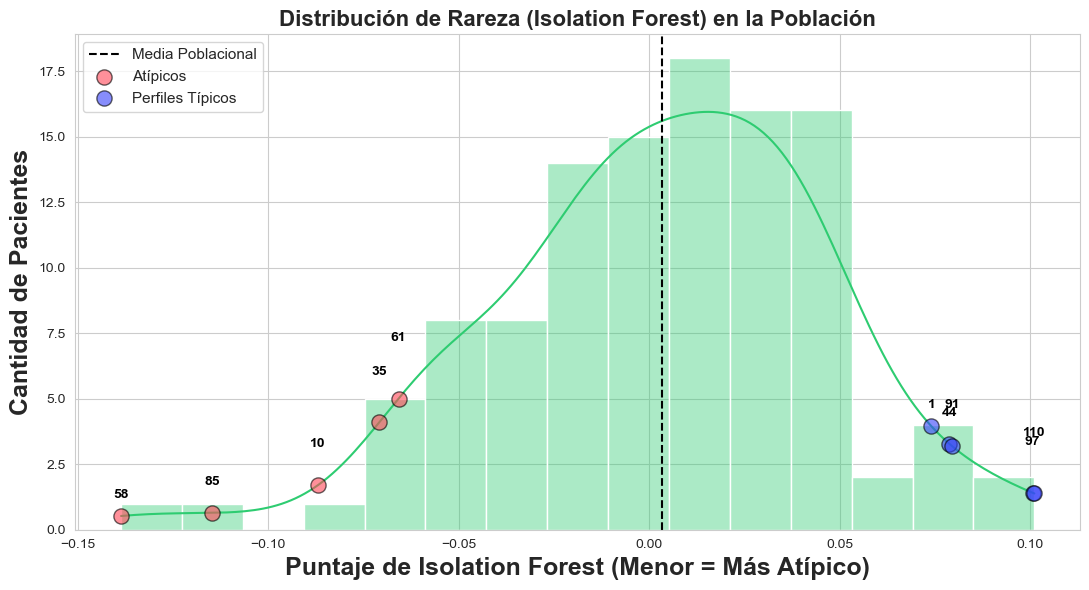

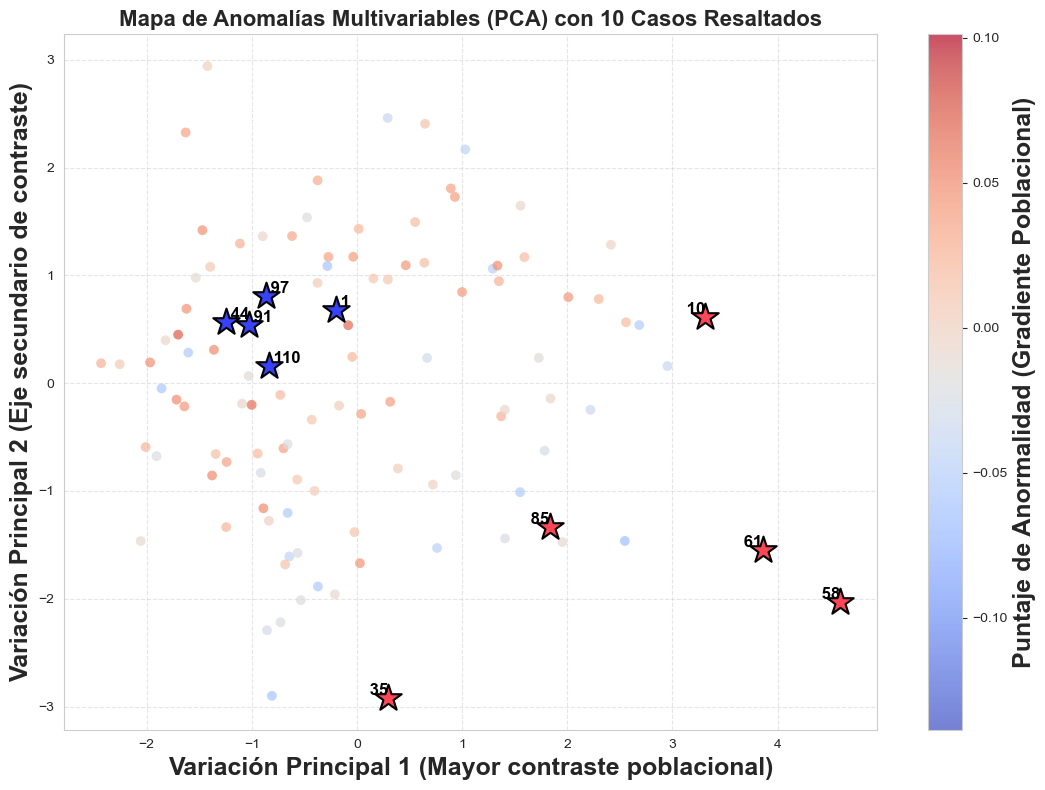

In [9]:
# 1. Selección y limpieza inicial de variables
cols_score = [
    'Microbiota_Stress', 'Categoria_Glucosa', 'Riesgo_cintura', '5.4', 
    'Diet_Score', 'Lifestyle_Score', 'IMC', 
    '4.1', '4.2', '1.3', 'Taquicardia_reposo', 'Temperatura', 'Fitzpatrick Scale'
]

cols_score = [col for col in cols_score if col in df_final.columns]

# 2. Estandarización de los datos (z-scores)
scaler_z = StandardScaler()
df_raw_score = df_final[cols_score].copy()

for col in cols_score:
    df_raw_score[col] = df_raw_score[col].fillna(df_raw_score[col].median())

Z_pacientes = scaler_z.fit_transform(df_raw_score)
df_Z = pd.DataFrame(Z_pacientes, columns=cols_score, index=df_final.index)

# 3. Detección de anomalías (Isolation Forest)
iso_forest = IsolationForest(contamination='auto', random_state=42)

iso_forest.fit(df_Z)

df_final['Nivel_Rareza'] = iso_forest.decision_function(df_Z)

df_ordenado = df_final.sort_values('Nivel_Rareza', ascending=True)

top_5_interesantes = df_ordenado.head(5) 
top_5_menos_interesantes = df_ordenado.tail(5)

# 4. Descubriendo el porqué de cada paciente
def obtener_habitos_clave(paciente_idx, es_anomalia=True):
    z_scores_paciente = df_Z.loc[paciente_idx]
 
    if es_anomalia:
        top_desviaciones = z_scores_paciente.abs().sort_values(ascending=False).head(3)
    else:
        top_desviaciones = z_scores_paciente.abs().sort_values(ascending=True).head(3)
        
    explicacion = []
    for col, valor_abs in top_desviaciones.items():
        valor_real = df_final.loc[paciente_idx, col]
        z_val = z_scores_paciente[col]
        
        if es_anomalia:
            tendencia = "anormalmente ALTO" if z_val > 0 else "anormalmente BAJO"
        else:
            tendencia = "idéntico al promedio"

        nombre_col = "Heces Bristol" if "imágenes" in col else col
        explicacion.append(f"- {nombre_col} ({tendencia}, valor original: {valor_real})")
        
    return explicacion

# 5. Reporte final en consola (Ajustado a "Típicos")
print(" LOS 5 PACIENTES MÁS INTERESANTES (Casos Atípicos / Extremos)")
for idx, row in top_5_interesantes.iterrows():
    print(f"\nPaciente ID: {idx}")
    print(f"Puntaje de Rareza: {row['Nivel_Rareza']:.3f} (Muy negativo)")
    for habito in obtener_habitos_clave(idx, es_anomalia=True):
        print(f"    {habito}")

print("\n LOS 5 PACIENTES MÁS TÍPICOS (El Promedio Poblacional)")
for idx, row in top_5_menos_interesantes.iterrows():
    print(f"\nPaciente ID: {idx}")
    print(f"Puntaje de Rareza: {row['Nivel_Rareza']:.3f} (Positivo/Típico)")
    for habito in obtener_habitos_clave(idx, es_anomalia=False):
         print(f"    {habito}")

# 6. Visualizaciones estadísticas avanzadas
sns.set_style("whitegrid")

# GRÁFICA 1: Curva de Densidad
plt.figure(figsize=(11, 6))

ax = sns.histplot(data=df_final, x='Nivel_Rareza', kde=True, 
                  color='#2ecc71', alpha=0.4, bins=15, edgecolor='white')

linea_kde = ax.lines[0]
x_curva = linea_kde.get_xdata()
y_curva = linea_kde.get_ydata()

media_rareza = df_final['Nivel_Rareza'].mean()
plt.axvline(media_rareza, color='black', linestyle='--', linewidth=1.5, label='Media Poblacional')

# Atípicos con transparencia y ajuste de texto para no encimarse
for i, (idx, row) in enumerate(top_5_interesantes.iterrows()):
    x_val = row['Nivel_Rareza']
    y_val = np.interp(x_val, x_curva, y_curva) 
    
    plt.scatter(x_val, y_val, color='#ff4757', s=120, edgecolor='black', zorder=5, alpha=0.6,
                label='Atípicos' if i == 0 else "")
    
    # Desplazamiento vertical dinámico (i*0.02) para que los IDs no se encimen si los puntos están juntos
    plt.text(x_val, y_val + (ax.get_ylim()[1] * (0.03 + i*0.02)), f'{idx}', color='black', 
             ha='center', va='bottom', fontsize=10, weight='bold')

# Perfiles Típicos (Azules) con transparencia y ajuste de texto
for i, (idx, row) in enumerate(top_5_menos_interesantes.iterrows()):
    x_val = row['Nivel_Rareza']
    y_val = np.interp(x_val, x_curva, y_curva) 
    
    plt.scatter(x_val, y_val, color='#3742fa', s=120, edgecolor='black', zorder=5, alpha=0.6,
                label='Perfiles Típicos' if i == 0 else "")
    
    # Desplazamiento vertical dinámico para evitar solapamiento de nombres
    plt.text(x_val, y_val + (ax.get_ylim()[1] * (0.03 + i*0.02)), f'{idx}', color='black', 
             ha='center', va='bottom', fontsize=10, weight='bold')

plt.title('Distribución de Rareza (Isolation Forest) en la Población', fontsize=16, weight='bold')
plt.xlabel('Puntaje de Isolation Forest (Menor = Más Atípico)', fontsize=18, weight='bold')
plt.ylabel('Cantidad de Pacientes', fontsize=18, weight='bold')

handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, labels, loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

# GRÁFICA 2: Análisis de Componentes Principales (PCA)

pca = PCA(n_components=2)
componentes = pca.fit_transform(Z_pacientes)
df_pca = pd.DataFrame(componentes, columns=['Componente_1', 'Componente_2'], index=df_final.index)

# Ahora sí, el código de la figura:
plt.figure(figsize=(11, 8))

scatter = plt.scatter(df_pca['Componente_1'], df_pca['Componente_2'], 
                      c=df_final['Nivel_Rareza'], cmap='coolwarm', s=50, alpha=0.7, edgecolors='none')

for idx, row in top_5_interesantes.iterrows():
    plt.scatter(df_pca.loc[idx, 'Componente_1'], df_pca.loc[idx, 'Componente_2'], 
                s=400, color='#ff4757', marker='*', edgecolors='black', linewidth=1.5, zorder=10)
    plt.text(df_pca.loc[idx, 'Componente_1'], df_pca.loc[idx, 'Componente_2'], f' {idx}', 
             color='black', fontsize=12, fontweight='bold', va='bottom', ha='right', zorder=11)

for idx, row in top_5_menos_interesantes.iterrows():
    plt.scatter(df_pca.loc[idx, 'Componente_1'], df_pca.loc[idx, 'Componente_2'], 
                s=400, color='#3742fa', marker='*', edgecolors='black', linewidth=1.5, zorder=10)
    plt.text(df_pca.loc[idx, 'Componente_1'], df_pca.loc[idx, 'Componente_2'], f' {idx}', 
             color='black', fontsize=12, fontweight='bold', va='bottom', ha='left', zorder=11)

colorbar = plt.colorbar(scatter)
colorbar.set_label('Puntaje de Anormalidad (Gradiente Poblacional)', fontsize=18, weight='bold')

plt.grid(linestyle='--', alpha=0.5)
plt.title('Mapa de Anomalías Multivariables (PCA) con 10 Casos Resaltados', fontsize=16, weight='bold')
plt.xlabel('Variación Principal 1 (Mayor contraste poblacional)', fontsize=18, weight='bold')
plt.ylabel('Variación Principal 2 (Eje secundario de contraste)', fontsize=18, weight='bold')
plt.tight_layout()
plt.show()

# 10 Segmentación Clínica y Perfilado de Salud (GMM)
En esta sección, el objetivo es agrupar a los pacientes en clústeres biológicos (tribus de salud). A diferencia de la detección de anomalías, aquí buscamos patrones colectivos para identificar grupos con necesidades clínicas similares.

Utilizamos Gaussian Mixture Models (GMM) por su capacidad superior de segmentación:

* Flexibilidad Geométrica: A diferencia de otros métodos, el GMM permite que los grupos tengan formas elípticas, adaptándose con precisión a la dispersión natural de los datos biológicos y de microbiota.

* Modelado Probabilístico: El algoritmo reconoce que la salud es un espectro; entiende que un paciente puede estar en una "zona gris" entre dos perfiles.

* Interpretación Semántica (Semáforo Clínico): Hemos mapeado los resultados del modelo a una escala de colores diagnóstica basada en el Metabolic Risk Score:

Verde (Bajo Riesgo): Pacientes con indicadores metabólicos óptimos y alta resiliencia.

Amarillo (Perfil Promedio): Población en niveles basales o preventivos.

Rojo (Disbiosis): Segmento con acumulación de factores de riesgo (inflamación, glucosa alterada u obesidad central).

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


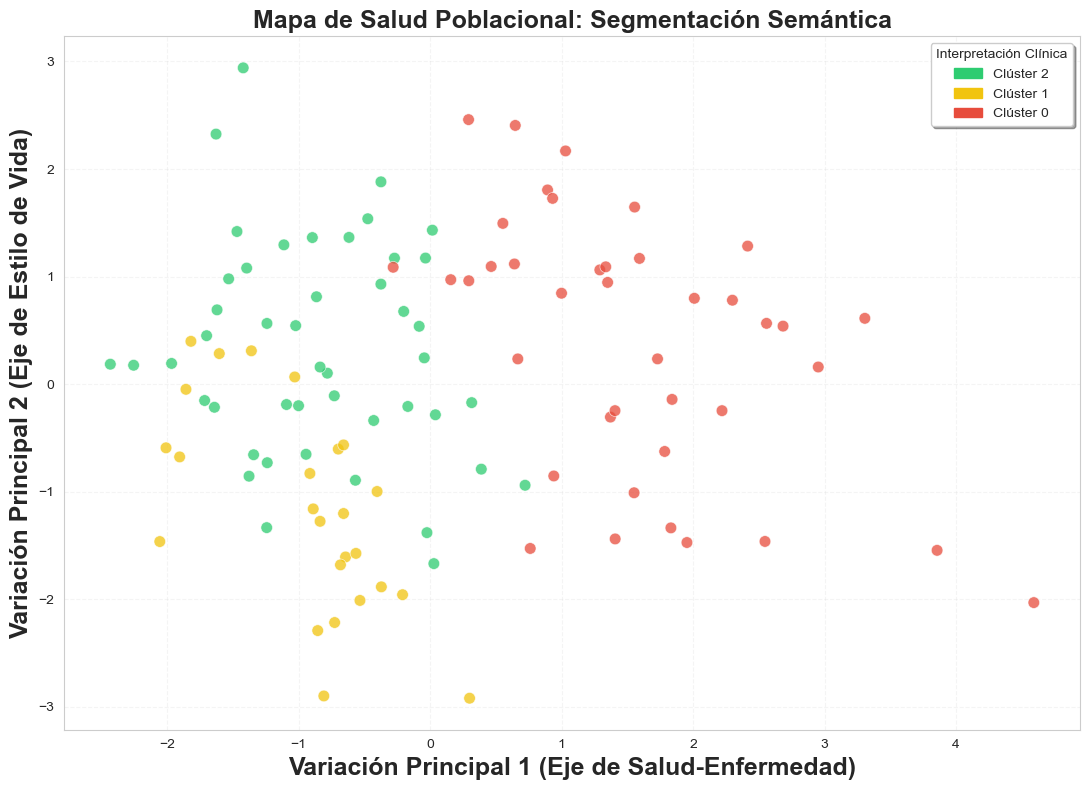

In [10]:
# 1. Entrenamos el modelo GMM
gmm = GaussianMixture(n_components=3, random_state=42)
df_final["Cluster"] = gmm.fit_predict(df_Z)

# Calculamos el promedio de riesgo metabólico por cluster
perfil_riesgo = df_final.groupby('Cluster')['Metabolic_Risk_Score'].mean()

# Identificamos matemáticamente los clusters extremos
id_cluster_riesgo = perfil_riesgo.idxmax()
id_cluster_sano = perfil_riesgo.idxmin()  

# El cluster restante será el 'Promedio'
todos_los_ids = set(perfil_riesgo.index)
id_cluster_promedio = list(todos_los_ids - {id_cluster_riesgo, id_cluster_sano})[0]

# Creamos un diccionario que mapea el ID del cluster con su color semántico
colores_clinicos = {
    id_cluster_sano: '#2ecc71',     
    id_cluster_promedio: '#f1c40f', 
    id_cluster_riesgo: '#e74c3c'      
}


colores_puntos = [colores_clinicos[cluster_id] for cluster_id in df_final['Cluster']]

# Graficando en espacio PCA
plt.figure(figsize=(11, 8))

plt.scatter(df_pca['Componente_1'], df_pca['Componente_2'],
            c=colores_puntos, s=70, alpha=0.75, edgecolors='white', linewidth=0.5)

# Creación de leyenda personalizada
leyenda_sano = mpatches.Patch(color=colores_clinicos[id_cluster_sano], label='Clúster 2')
leyenda_promedio = mpatches.Patch(color=colores_clinicos[id_cluster_promedio], label='Clúster 1')
leyenda_riesgo = mpatches.Patch(color=colores_clinicos[id_cluster_riesgo], label='Clúster 0')

plt.legend(handles=[leyenda_sano, leyenda_promedio, leyenda_riesgo], 
           loc='upper right', title='Interpretación Clínica', frameon=True, shadow=True)

plt.title("Mapa de Salud Poblacional: Segmentación Semántica", fontsize=18, weight='bold')
plt.xlabel("Variación Principal 1 (Eje de Salud-Enfermedad)", fontsize=18, weight='bold')
plt.ylabel("Variación Principal 2 (Eje de Estilo de Vida)", fontsize=18, weight='bold')
plt.grid(alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()

# 11 Perfilado Clínico: ¿Quién es quién en cada grupo?
Una vez que el algoritmo ha agrupado a los pacientes, realizamos un análisis de centroides (promedios). Esto nos permite traducir los números abstractos del modelo en perfiles médicos reales.

En esta sección analizamos las 6 variables maestras que definen la salud del paciente:

* IMC y Riesgo de Cintura: Determinan el estado antropométrico y la obesidad central.

* Diet y Lifestyle Score: Evalúan la calidad de los hábitos que nutren o agreden a la microbiota.

* Microbiota Stress: Mide el nivel de daño acumulado en el sistema digestivo.

* Categoría de Glucosa: Indica la estabilidad metabólica.

In [11]:
# Estas columnas resumen la salud física, metabólica y el estilo de vida.
variables_clave = [
    'IMC', 'Diet_Score', 'Microbiota_Stress',
    'Lifestyle_Score', 'Categoria_Glucosa', 'Riesgo_cintura'
]

# Cálculo de los "Centroides" del Cluster
perfil_clusters = df_final.groupby("Cluster")[variables_clave].mean()

# Reporte de diagnóstico por grupo
print(" DIAGNÓSTICO PROMEDIO POR CLUSTER (Perfiles Clínicos)")
print(perfil_clusters)

# NOTA PARA LA INTERPRETACIÓN
# Si el Cluster 2 tiene el 'Microbiota_Stress' más alto y el 'Diet_Score' más bajo, ese es el grupo de "Alto Riesgo" (Color Rojo en el gráfico anterior).
# El cluster con el 'Diet_Score' más alto suele ser el "Sano" (Verde).

 DIAGNÓSTICO PROMEDIO POR CLUSTER (Perfiles Clínicos)
               IMC  Diet_Score  Microbiota_Stress  Lifestyle_Score  Categoria_Glucosa  Riesgo_cintura
Cluster                                                                                              
0        23.371349   10.086957          13.217391       -16.086957           0.086957             0.0
1        30.908010    3.525000          14.175000       -18.850000           0.275000             1.0
2        22.976963   12.600000          17.000000       -22.880000           0.600000             0.0


# 12 Validación Estadística: Distribución por Clúster
Para confirmar que nuestra segmentación es robusta, realizamos un análisis visual de dispersión por variable. El objetivo es observar si las cajas de cada clúster están separadas o si se enciman demasiado.

Utilizamos Boxplots (Diagramas de Caja) para identificar:

* Mediana: La línea central de la caja.

* Rango Intercuartílico: El cuerpo de la caja (donde está el 50% de los pacientes).

* Bigotes y Outliers: Los puntos fuera de las líneas indican pacientes con valores inusuales dentro de su propio grupo.

Éxito clínico: Si las cajas de una variable (ej. Diet_Score) están a diferentes alturas y no se tocan, significa que esa variable es un excelente biomarcador para diferenciar a los grupos.

C:\Users\pauli\AppData\Local\Temp\ipykernel_424\1986880681.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Cluster_Nombre", y=var, data=df_grafica,


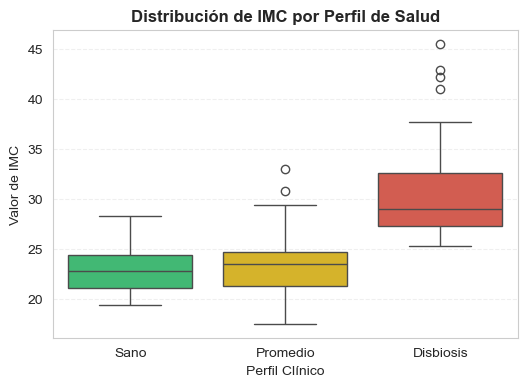

C:\Users\pauli\AppData\Local\Temp\ipykernel_424\1986880681.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Cluster_Nombre", y=var, data=df_grafica,


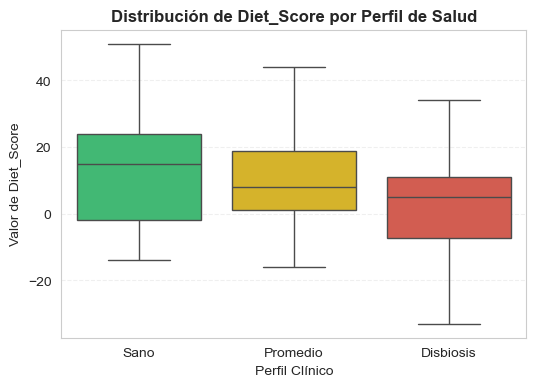

C:\Users\pauli\AppData\Local\Temp\ipykernel_424\1986880681.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Cluster_Nombre", y=var, data=df_grafica,


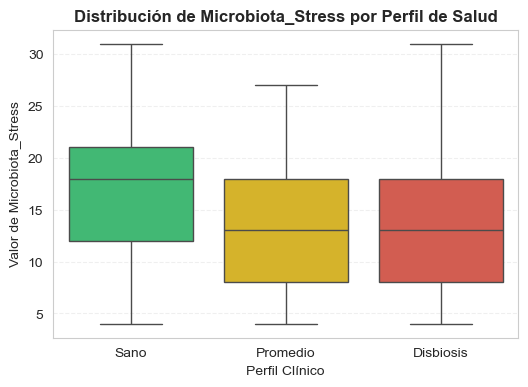

C:\Users\pauli\AppData\Local\Temp\ipykernel_424\1986880681.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Cluster_Nombre", y=var, data=df_grafica,


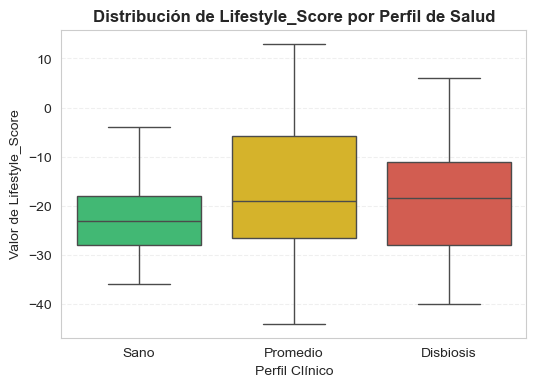

C:\Users\pauli\AppData\Local\Temp\ipykernel_424\1986880681.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Cluster_Nombre", y=var, data=df_grafica,


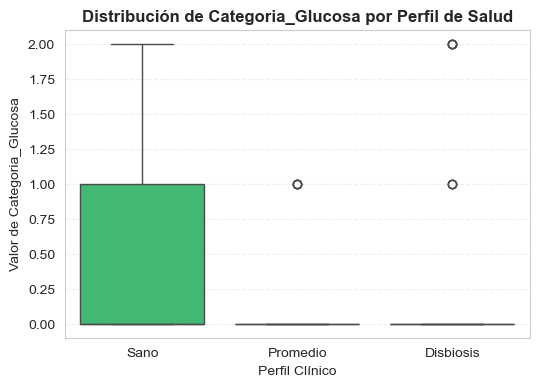

C:\Users\pauli\AppData\Local\Temp\ipykernel_424\1986880681.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Cluster_Nombre", y=var, data=df_grafica,


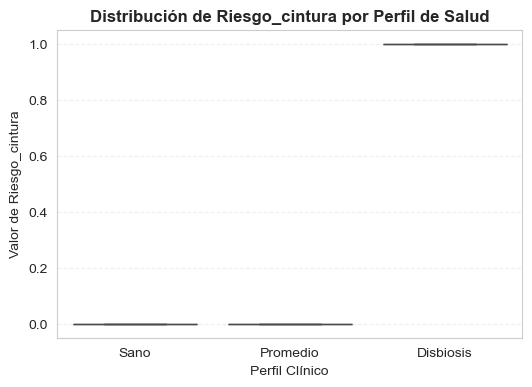

In [12]:
mapeo_nombres = {
    1: "Disbiosis",
    0: "Promedio",
    2: "Sano"
}

df_grafica = df_final.copy()
df_grafica["Cluster_Nombre"] = df_grafica["Cluster"].map(mapeo_nombres)

for var in variables_clave:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Cluster_Nombre", y=var, data=df_grafica, 
                order=["Sano", "Promedio", "Disbiosis"],
                palette={"Sano": "#2ecc71", "Promedio": "#f1c40f", "Disbiosis": "#e74c3c"})
    
    plt.title(f"Distribución de {var} por Perfil de Salud", fontsize=12, weight='bold')
    plt.xlabel("Perfil Clínico")
    plt.ylabel(f"Valor de {var}")
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    
    plt.show()

# 13 Validación Cruzada: Intersección de Perfiles y Anomalías
En esta sección, realizamos una validación cruzada para entender cómo se distribuyen las anomalías dentro de los grupos de salud identificados. Esto permite analizar si los pacientes en riesgo presentan también los perfiles más atípicos desde una perspectiva estadística.

Definiciones del Análisis:
* Perfil Normal (Población Común): Pacientes cuyos indicadores siguen el patrón estándar de su grupo. Representan el comportamiento típico de esa categoría de salud.
* Perfil Atípico (Anomalía): Pacientes que el modelo Isolation Forest identificó como casos únicos. Pueden representar perfiles clínicos complejos o combinaciones inusuales de biomarcadores de microbiota.

 RELACIÓN PERFIL CLÍNICO vs ANOMALÍA
                      Perfil Normal  Perfil Atípico
Cluster                                            
Promedio                         39               7
Alto Riesgo (Alerta)             16              24
Bajo Riesgo (Sano)                6              19


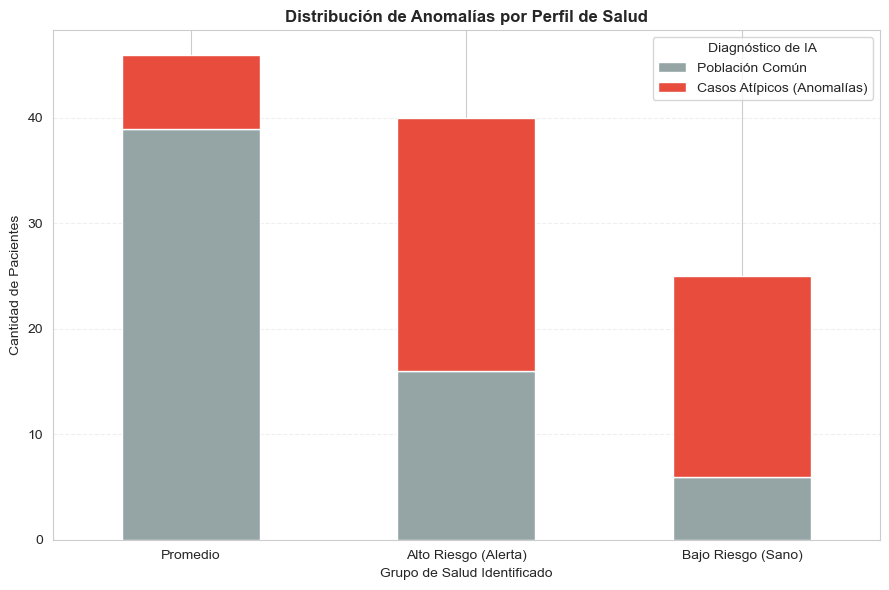

In [13]:
id_sano = df_final.groupby('Cluster')['IMC'].mean().idxmin()
id_riesgo = df_final.groupby('Cluster')['IMC'].mean().idxmax()
id_promedio = list(set(df_final['Cluster'].unique()) - {id_sano, id_riesgo})[0]

# Diccionario de traducción
nombres_mapeo = {
    id_sano: 'Bajo Riesgo (Sano)', 
    id_promedio: 'Promedio', 
    id_riesgo: 'Alto Riesgo (Alerta)'
}
# Creación de tabla
tabla = pd.crosstab(df_final["Cluster"], df_final["Nivel_Rareza"] < 0)
tabla.index = tabla.index.map(nombres_mapeo)
tabla.columns = ['Perfil Normal', 'Perfil Atípico']

print(" RELACIÓN PERFIL CLÍNICO vs ANOMALÍA")
print(tabla)

# Generación de gráfica de barras
tabla.plot(kind='bar', stacked=True, figsize=(9, 6), color=['#95a5a6', '#e74c3c'])

plt.title("Distribución de Anomalías por Perfil de Salud", fontsize=12, weight='bold')
plt.xlabel("Grupo de Salud Identificado")
plt.ylabel("Cantidad de Pacientes")
plt.xticks(rotation=0) 
plt.legend(title="Diagnóstico de IA", labels=['Población Común', 'Casos Atípicos (Anomalías)'])
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


# 14 Mapa de Dispersión: Coherencia entre Clústeres y Anomalías
En esta sección proyectamos ambos modelos (GMM e Isolation Forest) sobre el espacio de PCA. El objetivo es validar visualmente la estructura de la población:

* Los Colores (Fondo): Representan la pertenencia a los grupos de salud (Verde, Amarillo, Rojo).
* Los Puntos Rojos (Resaltados): Identifican a los pacientes marcados como anomalías.

Esta gráfica permite confirmar si las anomalías son simplemente pacientes de alto riesgo o si son individuos que se encuentran en los límites exteriores de cada grupo, desafiando la norma biológica del estudio.

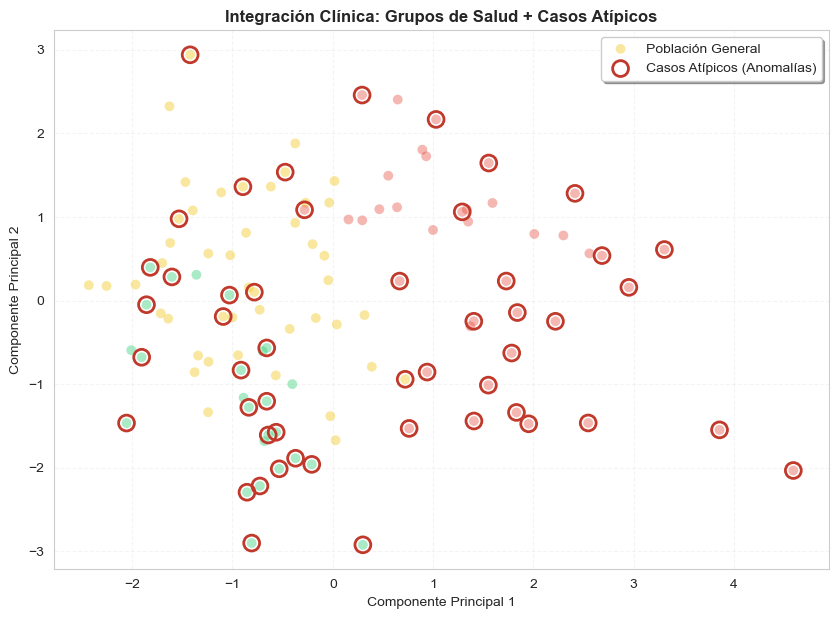

Se han resaltado 50 pacientes como anomalías sobre el mapa de clústeres.


In [14]:
# Identificación de IDs para mantener los colores de semáforo
id_sano = df_final.groupby('Cluster')['IMC'].mean().idxmin()
id_riesgo = df_final.groupby('Cluster')['IMC'].mean().idxmax()
id_promedio = list(set(df_final['Cluster'].unique()) - {id_sano, id_riesgo})[0]

# Paleta semántica 
colores_mapeo = {id_sano: '#2ecc71', id_promedio: '#f1c40f', id_riesgo: '#e74c3c'}
colores_puntos = [colores_mapeo[c] for c in df_final["Cluster"]]

plt.figure(figsize=(10, 7))

# Dibujamos la población general (Clusters)
plt.scatter(df_pca['Componente_1'], df_pca['Componente_2'],
            c=colores_puntos, s=50, alpha=0.4, edgecolors='none', label='Población General')

# Resaltar anomalías
anomalias = df_final[df_final["Nivel_Rareza"] < 0]

plt.scatter(df_pca.loc[anomalias.index, 'Componente_1'],
            df_pca.loc[anomalias.index, 'Componente_2'],
            color='none', edgecolor='#c0392b', s=130, linewidth=2, label='Casos Atípicos (Anomalías)')

plt.title("Integración Clínica: Grupos de Salud + Casos Atípicos", fontsize=12, weight='bold')
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.grid(alpha=0.2, linestyle='--')

plt.show()

print(f"Se han resaltado {len(anomalias)} pacientes como anomalías sobre el mapa de clústeres.")

# 15 Análisis de Importancia: Factores Determinantes de la Microbiota
En esta sección, implementamos un modelo de Random Forest Classifier para identificar qué variables biológicas y de estilo de vida tienen mayor peso en la conformación de los grupos de salud.

Este análisis permite abrir la caja negra de la Inteligencia Artificial y entender los biomarcadores clave:

* Variables con mayor peso: Son los principales diferenciadores clínicos (ej. si el IMC es el más alto, significa que el peso es la variable que más separa a los sanos de los enfermos).
* Variables con menor peso: Factores que, aunque importantes, no fueron decisivos para la clasificación actual de los pacientes.

C:\Users\pauli\AppData\Local\Temp\ipykernel_424\3479840478.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancias.values, y=importancias.index, palette="Blues_r")


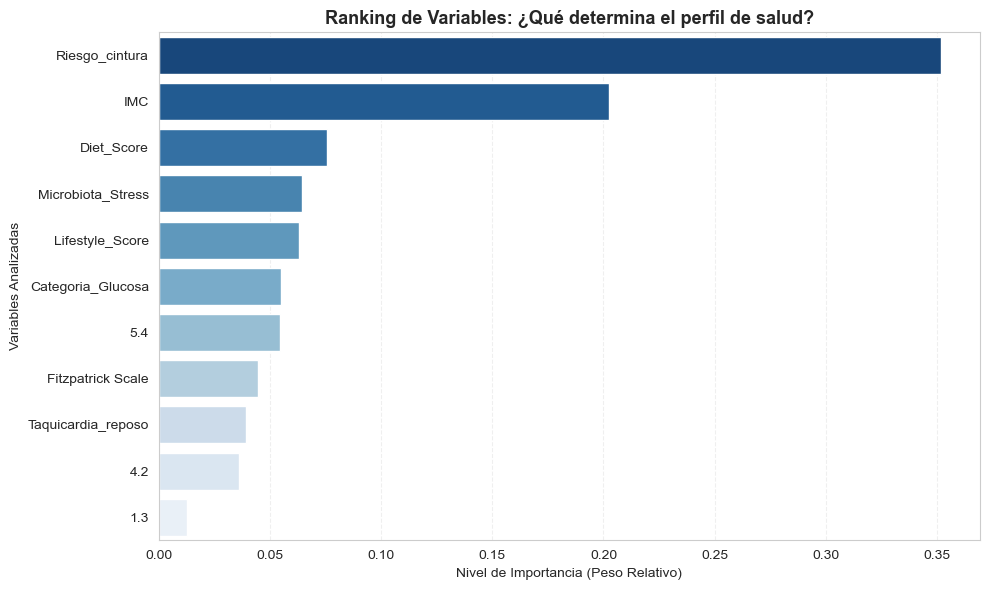

 TOP VARIABLES DETERMINANTES
Riesgo_cintura        0.351719
IMC                   0.202645
Diet_Score            0.075661
Microbiota_Stress     0.064253
Lifestyle_Score       0.063251
Categoria_Glucosa     0.054834
5.4                   0.054717
Fitzpatrick Scale     0.044551
Taquicardia_reposo    0.039249
4.2                   0.036283
1.3                   0.012835
dtype: float64


In [15]:
# Preparación de datos
X = df_Z  # Variables normalizadas
y = df_final["Cluster"]  # Etiquetas de los grupos (Sano, Promedio, Riesgo)

# Entrenamiento del modelo
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X, y)

# Cálculo y ordenamiento de importancias
importancias = pd.Series(rf.feature_importances_, index=df_Z.columns)
importancias = importancias.sort_values(ascending=False)

# Visualización de Importancia
plt.figure(figsize=(10, 6))
sns.barplot(x=importancias.values, y=importancias.index, palette="Blues_r")

plt.title("Ranking de Variables: ¿Qué determina el perfil de salud?", fontsize=13, weight='bold')
plt.xlabel("Nivel de Importancia (Peso Relativo)")
plt.ylabel("Variables Analizadas")
plt.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Reporte en consola
print(" TOP VARIABLES DETERMINANTES")
print(importancias.head(11))

# 16 Mapa de Calor: Caracterización de Perfiles Clínicos
En esta sección, generamos un Heatmap que resume el promedio de todas las variables clave para cada clúster. Esta visualización funciona como un tablero de diagnóstico:

* Eje Horizontal (X): Las variables analizadas (IMC, Riesgo Cintura, Dieta, etc.).

* Eje Vertical (Y): Los perfiles identificados (Sano, Promedio, Riesgo).

* Escala de Color: Los colores intensos (rojos) indican valores altos, mientras que los colores fríos (azules) indican valores bajos.

Este mapa permite identificar rápidamente qué combinaciones de factores definen a cada grupo. Por ejemplo, podemos observar si el grupo de Alto Riesgo tiene simultáneamente niveles altos de Riesgo Cintura y niveles bajos de Lifestyle Score.

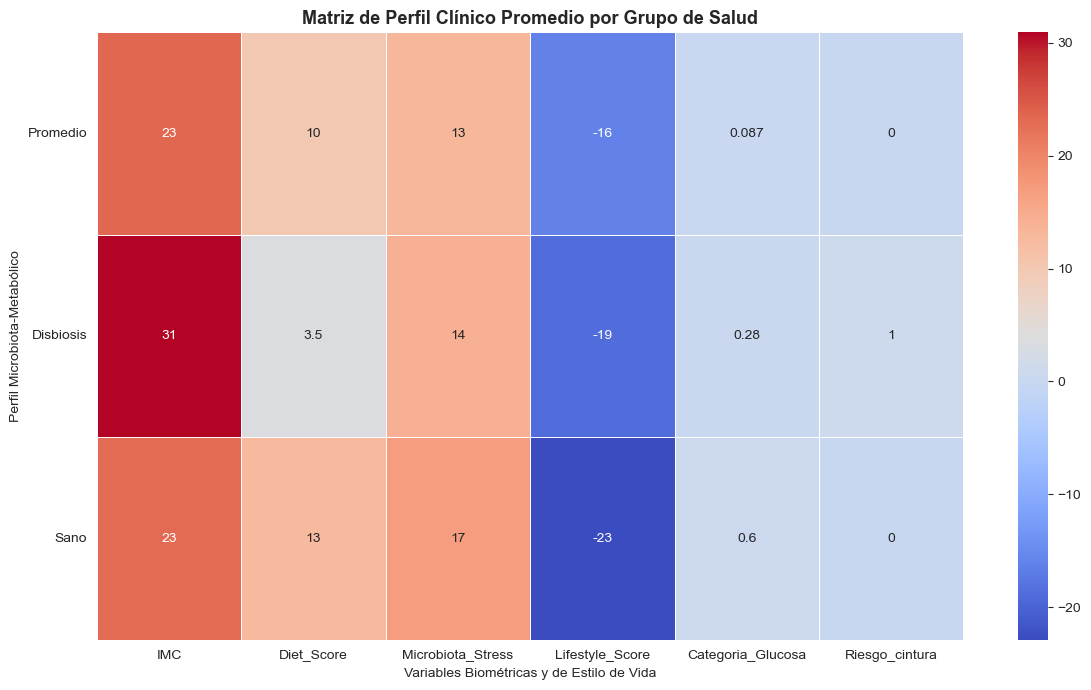

In [16]:
perfil_con_nombres = perfil_clusters.copy()

perfil_con_nombres.index = perfil_con_nombres.index.map({
    1: 'Disbiosis', 
    0: 'Promedio', 
    2: 'Sano'
})

plt.figure(figsize=(12, 7))

sns.heatmap(perfil_con_nombres, annot=True, cmap="coolwarm", fmt=".2g", linewidths=0.5)

plt.xticks(rotation=0, fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.title("Matriz de Perfil Clínico Promedio por Grupo de Salud", fontsize=13, weight='bold')
plt.ylabel("Perfil Microbiota-Metabólico")
plt.xlabel("Variables Biométricas y de Estilo de Vida")

plt.tight_layout()
plt.show()

# 17 Análisis de Cargas: Interpretación de Componentes Principales
En esta sección, descomponemos las Cargas del PCA para entender el significado biológico de nuestras dimensiones reducidas. Las cargas varían entre -1 y 1:

* Carga cercana a 1 o -1: La variable tiene una influencia muy fuerte en ese componente.
* Carga cercana a 0: La variable casi no aporta información a ese eje.


CARGAS DEL PCA:
                         PC1       PC2
Riesgo_cintura      0.573939  0.186031
IMC                 0.572845  0.043056
Fitzpatrick Scale   0.323566  0.321298
Categoria_Glucosa   0.150110 -0.460456
Taquicardia_reposo  0.115579 -0.160844
4.2                 0.097200  0.346378
Microbiota_Stress   0.090349 -0.352087
1.3                -0.064696 -0.074277
5.4                -0.129125 -0.165983
Lifestyle_Score    -0.153745  0.531029
Diet_Score         -0.373830  0.251822


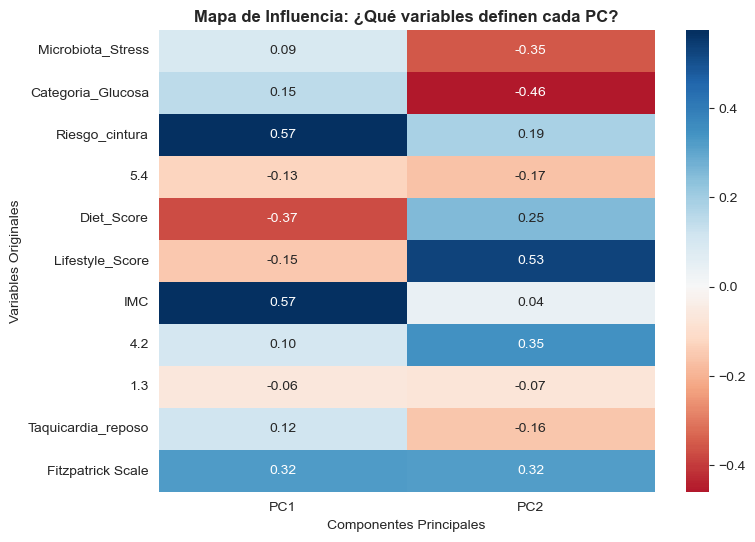

In [17]:
# Creamos el DataFrame de cargas (Loadings)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=df_Z.columns
)

# Mostramos el ranking en consola
print("\nCARGAS DEL PCA:")
print(loadings.sort_values(by="PC1", ascending=False))

# Heatmap de Influencia
plt.figure(figsize=(8, 6))
sns.heatmap(loadings, annot=True, cmap='RdBu', center=0, fmt=".2f")

plt.title("Mapa de Influencia: ¿Qué variables definen cada PC?", fontsize=12, weight='bold')
plt.ylabel("Variables Originales")
plt.xlabel("Componentes Principales")
plt.show()

# 18 Resumen de Influencia: Los Protagonistas del PCA
En este paso, aislamos las 5 variables con mayor impacto en cada Componente Principal. Esto nos permite definir qué aspectos biológicos explican la mayor parte de la diferencia entre nuestros pacientes.

* PC1 (Dimensión Primaria): Define la dirección de mayor variabilidad en los datos. Si las variables aquí son el IMC y la Cintura, este eje separa a los cuerpos por su composición física.
* PC2 (Dimensión Secundaria): Define la siguiente capa de información (estilo de vida y estrés) que el primer eje no alcanzó a explicar.

In [18]:
# Análisis de Fuerza (Valor Absoluto) para PC1
print("\nESTRUCTURA BIOLÓGICA DEL PC1 (Eje X): ")
print(loadings["PC1"].abs().sort_values(ascending=False).head(5))

# 2. Análisis de Fuerza (Valor Absoluto) para PC2
print("\nESTRUCTURA BIOLÓGICA DEL PC2 (Eje Y):")
print(loadings["PC2"].abs().sort_values(ascending=False).head(5))


ESTRUCTURA BIOLÓGICA DEL PC1 (Eje X): 
Riesgo_cintura       0.573939
IMC                  0.572845
Diet_Score           0.373830
Fitzpatrick Scale    0.323566
Lifestyle_Score      0.153745
Name: PC1, dtype: float64

ESTRUCTURA BIOLÓGICA DEL PC2 (Eje Y):
Lifestyle_Score      0.531029
Categoria_Glucosa    0.460456
Microbiota_Stress    0.352087
4.2                  0.346378
Fitzpatrick Scale    0.321298
Name: PC2, dtype: float64
